In [51]:
import numpy as np
from scipy import constants
from scipy.integrate import dblquad
import tabulate
import pandas as pd
import matplotlib.pyplot as plt
from IonChainTools import calcPositions,lengthScale,ion_position_potential
from tweezer_functions import *
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths

In [52]:
#setting up the x_pos and y_pos and z_pos to have a zoomed out image of both TEM10 and Gaussian beams, and to find the power of both beams.
w0 = 5e-6
P0 = 100e-3
n = 1
E0 = np.sqrt(2*P0 / (c*eps0*n*w0**2*n*pi))
x_pos = np.arange(-4*w0,4*w0,0.001e-6)
y_pos = 0
z_pos = 0
wz = beam_propogation(w0,z_pos,tweezer_wavelength)
gaussian_intensity = intensity(x_pos,y_pos,P0, wz)
gaussian_potential =  potential_position_dependent(omega_res,linewidths,omega_tweezer,gaussian_intensity)  
M_squared_Gaussian = 1
M_squared_TEM10 = 3

theta_gaussian = half_angle_beam_divergence(M_squared_Gaussian,w0,tweezer_wavelength)
theta_TEM10 = half_angle_beam_divergence(M_squared_TEM10,w0,tweezer_wavelength)

TEM10 = intensity_TEM10(x_pos,y_pos,w0,wz,E0,n)
tem10_potential = potential_position_dependent(omega_res,linewidths,omega_tweezer,TEM10)
print("Half-Angle Beam Divergence of Gaussian beam [$\degree$]",theta_gaussian*180/pi)
print("Half-Angle Beam Divergence of TEM10 beam [$\degree$]",theta_TEM10*180/pi)

power_gaussian,error_gaussian = dblquad(intensity,min(x_pos),max(x_pos),min(x_pos),max(x_pos),args = (P0,wz))
power_tem,error_tem = dblquad(intensity_TEM10,min(x_pos),max(x_pos),min(x_pos),max(x_pos),args = (w0,wz,E0,n))
#print(np.isclose(power_gaussian,power_tem,atol = 1e-9))
print("Power TEM [W]",power_tem)
print("Power Gaussian [W]", power_gaussian)

Half-Angle Beam Divergence of Gaussian beam [$\degree$] 1.940503309118053
Half-Angle Beam Divergence of TEM10 beam [$\degree$] 5.821509927354159
Power TEM [W] 0.09999999999999164
Power Gaussian [W] 0.09999999999999977


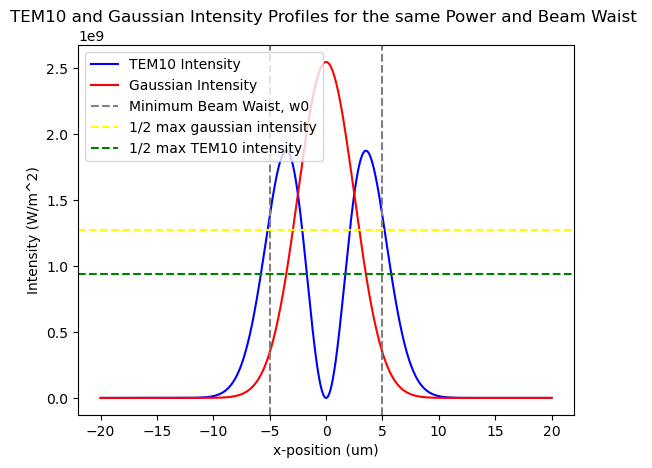

In [53]:
#Now I just want to see what the TEM10 and Gaussian beams look like
plt.xlabel("x-position (um)")
plt.ylabel("Intensity (W/m^2)") 
plt.plot(x_pos*1e6,TEM10,'b-',label = "TEM10 Intensity")
plt.legend(loc = 'upper right')
plt.plot(x_pos*1e6,gaussian_intensity,'r-',label = "Gaussian Intensity")
plt.axvline(x = w0*1e6,linestyle = "dashed",color = "gray", label = "Minimum Beam Waist, w0")
plt.axvline(x = -w0*1e6,linestyle = "dashed", color = "gray")
plt.axhline(y = max(gaussian_intensity)/2,linestyle = "dashed",color = "yellow",label = "1/2 max gaussian intensity")
plt.axhline(y = max(TEM10)/2,linestyle = "dashed",color = "green",label = "1/2 max TEM10 intensity")
plt.legend(loc = "best")
plt.title("TEM10 and Gaussian Intensity Profiles for the same Power and Beam Waist ")
plt.show()

In [54]:
find_fwhm_gaussian = np.where(np.isclose(max(gaussian_intensity)/2,gaussian_intensity,atol = 5e5))
fwhm_gaussian = x_pos[find_fwhm_gaussian][1] - x_pos[find_fwhm_gaussian][0]
print(gaussian_intensity[np.where(np.isclose(max(gaussian_intensity)/2,gaussian_intensity,atol = 5e5))])
print(max(gaussian_intensity)/2)
print(find_fwhm_gaussian)
print(fwhm_gaussian/w0)

[1.27295475e+09 1.27355441e+09 1.27355441e+09 1.27295475e+09]
1273239544.7351627
(array([17056, 17057, 22943, 22944]),)
0.0001999999999997609


In [55]:
find_fwhm_tem = np.where(np.isclose(max(TEM10)/2,TEM10,atol = 5e5))
fwhm_tem = [x_pos[find_fwhm_tem][1] - x_pos[find_fwhm_tem][0],x_pos[find_fwhm_tem][3]-x_pos[find_fwhm_tem][2]]
print(TEM10[np.where(np.isclose(max(TEM10)/2,TEM10,atol = 5e5))])
print(max(TEM10)/2)
print(fwhm_tem)
print(fwhm_tem[0]/w0)

[9.36326271e+08 9.36869693e+08 9.36970272e+08 9.36970271e+08
 9.36869693e+08 9.36326271e+08]
936797271.8284147
[9.999999999988046e-10, 3.4059999999959284e-06]
0.0001999999999997609


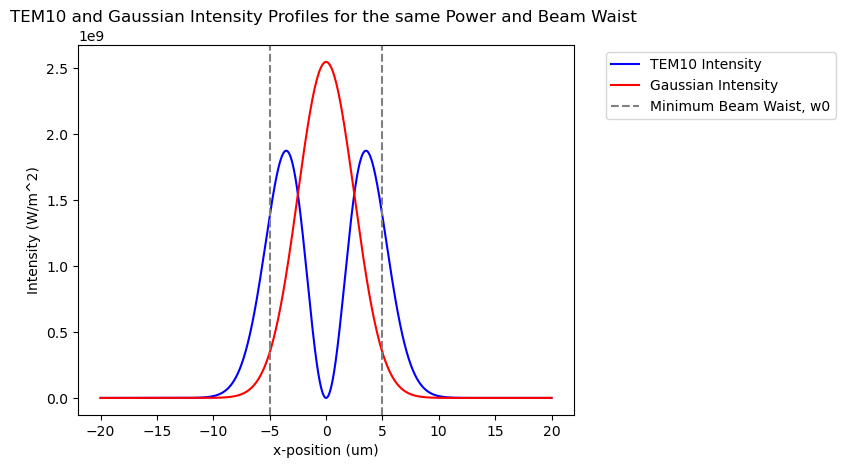

In [56]:
#Now I just want to see what the TEM10 and Gaussian beams look like
plt.xlabel("x-position (um)")
plt.ylabel("Intensity (W/m^2)") 
plt.plot(x_pos*1e6,TEM10,'b-',label = "TEM10 Intensity")
plt.legend(loc = 'upper right')
plt.plot(x_pos*1e6,gaussian_intensity,'r-',label = "Gaussian Intensity")
plt.axvline(x = w0*1e6,linestyle = "dashed",color = "gray", label = "Minimum Beam Waist, w0")
plt.axvline(x = -w0*1e6,linestyle = "dashed", color = "gray")
"""plt.axvline(x =x_pos[find_fwhm_gaussian][1]*1e6 ,linestyle = "dashed", color = "yellow",label = "FWHM Gaussian")
plt.axvline(x =x_pos[find_fwhm_gaussian][0]*1e6 ,linestyle = "dashed", color = "yellow")
plt.axvline(x = x_pos[find_fwhm_tem][1]*1e6,linestyle = "dashed", color = "green",label = "FWHM TEM10")
plt.axvline(x = x_pos[find_fwhm_tem][0]*1e6,linestyle = "dashed", color = "green")
plt.axvline(x = x_pos[find_fwhm_tem][3]*1e6,linestyle = "dashed", color = "green")
plt.axvline(x = x_pos[find_fwhm_tem][2]*1e6,linestyle = "dashed", color = "green")
plt.axhline(y = max(TEM10)/2,linestyle = "dashed", color = "gray")"""
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("TEM10 and Gaussian Intensity Profiles for the same Power and Beam Waist ")
plt.show()

In [57]:
mid_variable = np.where(np.isclose(max(TEM10),TEM10,atol = 5e5))[0]
print(mid_variable)
center = x_pos[mid_variable][0]


[16423 16424 16425 16426 16427 16428 16429 16430 16431 16432 16433 16434
 16435 16436 16437 16438 16439 16440 16441 16442 16443 16444 16445 16446
 16447 16448 16449 16450 16451 16452 16453 16454 16455 16456 16457 16458
 16459 16460 16461 16462 16463 16464 16465 16466 16467 16468 16469 16470
 16471 16472 16473 16474 16475 16476 16477 16478 16479 16480 16481 16482
 16483 16484 16485 16486 16487 16488 16489 16490 16491 16492 16493 16494
 16495 16496 16497 16498 16499 16500 16501 16502 16503 16504 16505 23495
 23496 23497 23498 23499 23500 23501 23502 23503 23504 23505 23506 23507
 23508 23509 23510 23511 23512 23513 23514 23515 23516 23517 23518 23519
 23520 23521 23522 23523 23524 23525 23526 23527 23528 23529 23530 23531
 23532 23533 23534 23535 23536 23537 23538 23539 23540 23541 23542 23543
 23544 23545 23546 23547 23548 23549 23550 23551 23552 23553 23554 23555
 23556 23557 23558 23559 23560 23561 23562 23563 23564 23565 23566 23567
 23568 23569 23570 23571 23572 23573 23574 23575 23

R-Squared value 0.9997466475870045
Fit Frequency [2 Pi x kHz] 12.438982245214175
Analytical Frequency [2 Pi x MHz] 0.08026117267682446
Ratio of Fit to Analytical Frequencies  0.9737763338457329


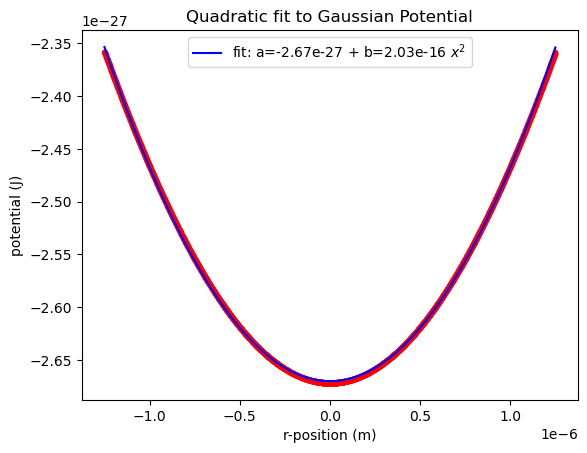

In [85]:
#ok now I want to find the fits for both the gaussian beam and for the tem10 beam 
x_pos = np.arange(-(0.25)*w0,(0.25)*w0,0.001e-6)
gaussian_intensity = intensity(x_pos,y_pos,P0, wz)
gaussian_potential =  potential_position_dependent(omega_res,linewidths,omega_tweezer,gaussian_intensity)  
def quadratic(x,a,b):
    return a+b*(x**2)
xdata = x_pos
ydata = gaussian_potential
popt, pcov = curve_fit(quadratic, xdata, ydata)
#calculating the r-squared value of the fit
alpha_x = tuple(popt)[1]
residuals = ydata-  quadratic(xdata, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((ydata-np.mean(ydata))**2)
r_squared = 1 - (ss_res / ss_tot)
print("R-Squared value",r_squared)
#calculating the frequency from the fit 
fit = np.sqrt(2*popt[1]/m)
print("Fit Frequency [2 Pi x kHz]",fit*1e-3 / (2*pi))
U = potential(omega_tweezer,linewidths,omega_res,P0,w0)
test = tweezer_optical_potential_to_trap_frequency(tweezer_wavelength,linewidths,omega_res,P0,w0,m,U)
print("Analytical Frequency [2 Pi x MHz]",test[0]*1e-6)
print("Ratio of Fit to Analytical Frequencies ",fit/test[0])

plt.plot(xdata,ydata,'r.')
plt.plot(xdata,quadratic(xdata, *popt) ,'b-',label=f'fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^{{2}}$')
plt.xlabel("r-position (m)")
plt.ylabel("potential (J)")
plt.title("Quadratic fit to Gaussian Potential")
plt.legend()
plt.show()

R-Squared value 0.999066560944357
Fit Frequency [2Pi kHz] 15.316838950576257
Center of Node [nm] -3546.567626200116


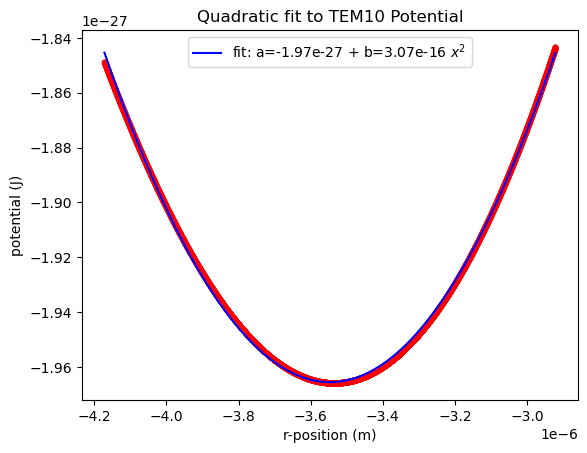

In [84]:
range_width = w0*0.25  # Total range
num_points = 10000  # Define the number of points in the range
x_pos = np.linspace(center - range_width / 2, center + range_width / 2, num_points)
y_pos=0
TEM10 = intensity_TEM10(x_pos,y_pos,w0,wz,E0,n)
tem10_potential = potential_position_dependent(omega_res,linewidths,omega_tweezer,TEM10) 
def fitting_function(x,a,b,x0):
    #x0 = center
    return a + b*(x - x0)**2
xdata = x_pos
ydata = tem10_potential
popt, pcov = curve_fit(fitting_function, xdata, ydata,p0 = [-1.385153-26,6e-14,center]) 
#calculating the r-squared value of the fit
alpha_x = tuple(popt)[1]
residuals = ydata-  fitting_function(xdata, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((ydata-np.mean(ydata))**2)
r_squared = 1 - (ss_res / ss_tot)
print("R-Squared value",r_squared)
#calculating the frequency from the fit 
fit_tem = np.sqrt(2*popt[1]/m)
fit_center = popt[2]
print("Fit Frequency [2Pi kHz]",fit_tem*1e-3 / (2*pi))
print("Center of Node [nm]",popt[2]*1e9)


plt.plot(xdata,ydata,'r.')
plt.plot(xdata,fitting_function(xdata, *popt) ,'b-',label=f'fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^{{2}}$')
plt.xlabel("r-position (m)")
plt.ylabel("potential (J)")
plt.title("Quadratic fit to TEM10 Potential")
plt.legend()
plt.show()

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


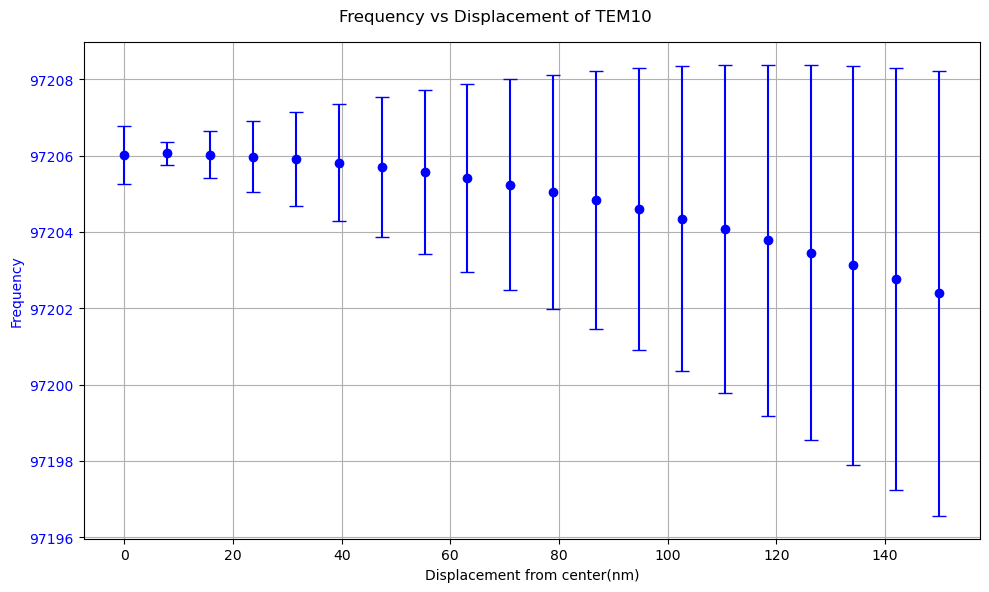

In [83]:
dial_values = np.linspace(0, 0.03, 20)  # Keep the original range
num_points = 1000  # Define the number of points for r_pos
center = fit_center
results, ratios, errors, positions = [], [], [], []
omega_rf_axial = 1 * 2 * pi * 1e6
ionspacing = ion_spacing(1, omega_rf_axial)

for dial in dial_values:
    if dial == 0:
        range_width = 0.001e-5
    else:
        range_width = (w0 / 2) * (dial + dial * 0.025)
    
    x_pos = np.linspace(center - range_width / 2, center + range_width / 2, num_points)
    TEM10 = intensity_TEM10(x_pos, y_pos, w0, wz, E0, n)
    ydata = potential_position_dependent(omega_res, linewidths, omega_tweezer, TEM10) 
    
    popt, pcov = curve_fit(fitting_function, x_pos, ydata, p0=[-1.385153e-26, 6e-14, center])
    fit_frequency = np.sqrt(2 * popt[1] / m)
    perr = np.sqrt(np.diag(pcov))
    fit_error = np.abs(fit_frequency * (perr[1] / popt[1]))
    
    displacement = w0 * dial  # Keep displacement as is
    omega_tw_radial = fit_frequency
      # Solve for tweezer-on position with fsolve
    tweeze_on, info, ier, msg = fsolve(
        pot_derivative_with_tweeze, 
        ionspacing[0], 
        args=(omega_rf_axial, omega_tw_radial, [0], displacement), 
        full_output=True
    )
    # Check if fsolve succeeded
    if ier != 1:
        print(f"⚠️ Warning: fsolve did not converge for dial={dial:.2f}. Message: {msg}")
        tweeze_on = [ionspacing[0]]  # Default to initial guess if fsolve fails
    


    positions.append(tweeze_on[0])
    
    results.append((dial, fit_frequency))
    ratios.append(fit_frequency)
    errors.append(fit_error)

positions = np.array(positions) * 1e9  # Convert to nm
print(positions)
displacements_nm = dial_values * w0 * 1e9  # Convert displacement to um for x-axis

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot frequency with errors
ax1.errorbar(displacements_nm, ratios, yerr=errors, fmt='o', label='Fit Frequency', color='blue', capsize=5)  
ax1.set_xlabel('Displacement from center(nm)')  
ax1.set_ylabel('Frequency', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Highlight the center point (dial == 0)
#center_index = np.argmin(np.abs(dial_values))  # Find the index closest to zero
#ax1.scatter(displacements_nm[center_index], ratios[center_index], color='black', edgecolors='white', s=100, label='Center Point', zorder=3)

# Second y-axis for ion position
"""ax2 = ax1.twinx()
ax2.plot(displacements_nm, positions, 'o', color='red', label='Ion Position')  
ax2.set_ylabel('Ion Position (nm)', color='red')
ax2.tick_params(axis='y', labelcolor='red')"""

fig.suptitle('Frequency vs Displacement of TEM10')
ax1.grid(True)
fig.tight_layout()
plt.show()


In [112]:
from IPython.display import display, Markdown

# Create a DataFrame for the Gaussian table
data_gaussian = {
    'Column 1': ['w0 [um]', 'FWHM [um]', 'Power [mW]', r'$\theta_{x}\degree$', r'$\omega_{x}$ [2Pi kHz]'],
    'Column 2': [w0*1e6, w0*1.18*1e6, power_gaussian*1e3, theta_gaussian*180/pi, fit*1e-3/(2*pi)]
}

df_table_gaussian = pd.DataFrame(data_gaussian)

# Create a DataFrame for the TEM10 table
data_tem10 = {
    'Column 1': ['w0 [um]', 'FWHM [um]', 'Distance between traps [um]','Approximate Axial Trap freq required (N=3) [2 Pi Hz]','Power [mW]', r'$\theta_{x}\degree$', r'$\omega_{x}$ [2Pi kHz]'],
    'Column 2': [w0*1e6, w0*0.8*1e6, np.abs(center*2)*1e6,0.5,power_tem*1e3, theta_TEM10*180/pi, fit_tem*1e-3/(2*pi)]
}

df_table_tem10 = pd.DataFrame(data_tem10)

# Function to convert DataFrame to Markdown table
def df_to_markdown(df):
    return df.to_markdown(index=False)

# Display the tables
print("Gaussian")
display(Markdown(df_to_markdown(df_table_gaussian)))

print("TEM10")
display(Markdown(df_to_markdown(df_table_tem10)))

Gaussian


| Column 1               |   Column 2 |
|:-----------------------|-----------:|
| w0 [um]                |     5      |
| FWHM [um]              |     5.9    |
| Power [mW]             |   100      |
| $\theta_{x}\degree$    |     1.9405 |
| $\omega_{x}$ [2Pi kHz] |    12.439  |

TEM10


| Column 1                                             |   Column 2 |
|:-----------------------------------------------------|-----------:|
| w0 [um]                                              |    5       |
| FWHM [um]                                            |    4       |
| Distance between traps [um]                          |    7.09334 |
| Approximate Axial Trap freq required (N=3) [2 Pi Hz] |    0.5     |
| Power [mW]                                           |  100       |
| $\theta_{x}\degree$                                  |    5.82151 |
| $\omega_{x}$ [2Pi kHz]                               |   15.3168  |

In [49]:
N = 7
omega_a = 0.2e6*2*pi
ion_spacing(N,omega_a)

[array([-2.93295353e-05, -1.83807521e-05, -8.93650074e-06, -1.00422500e-17,
         8.93650074e-06,  1.83807521e-05,  2.93295353e-05]),
 [1.0948783227725495e-05,
  9.444251378388233e-06,
  8.936500740407891e-06,
  8.936500740406448e-06,
  9.444251378377374e-06,
  1.094878322782183e-05]]

In [ ]:
N = 3
tweezed_ions = [0,1]
omega_a = 0.5e6*2*pi*np.ones(N)
omega_tweezer_r = np.zeros(N)
omega_tweezer_r[tweezed_ions] = fit_tem
omega_combined_ar = np.sqrt(omega_tweezer_r**2 + omega_a**2)
ueq = ion_spacing(N,omega_a)[0]
ar_modes = mode_calc_a(m,omega_combined_ar,ueq,N)
base = mode_calc_a(m,omega_a,ueq,N)

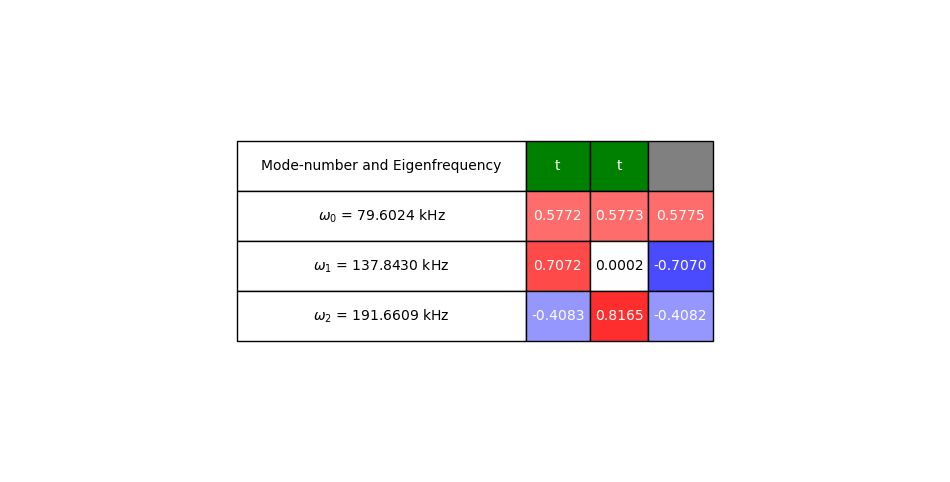

In [107]:
import matplotlib.colors as mcolors
data = ar_modes

# Creating the plot
fig, ax = plt.subplots(figsize=(12, 2 * len(data)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(data):
    # Convert omega from radians per second to kHz
    omega_mhz = (omega / (2 * np.pi)) / 1e3
    formatted_values = [f"{value:.4f}" for value in values]
    omega_label = f"$\omega_{{{index}}}$ = {omega_mhz:.4f} kHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels

column_labels = ['Mode-number and Eigenfrequency']  # Start with the label for the frequency column
for i in range(len(data[0][1])):
    if i  in [0,1]:  # These columns will have 't'
        column_labels.append('t')
    else:
        column_labels.append(' ')  # Other columns remain blank
# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(data[0][1]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=-1, vmax=1)

light_gray_columns = [2]
# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.3 < value < 0.3 else 'white')

# Special coloring for the first row
light_gray_columns = [0,1,2]
for j in range(1, len(column_labels)):  # Start from 1 to skip the first cell
    if j in light_gray_columns:
        table[0, j].set_facecolor('green')  # Set specified columns' background to blue
        table[0,j].set_text_props(color = 'white')
    else:
        table[0, j].set_facecolor('gray')  # Set other columns' background to gray
table[0, 0].set_facecolor('white')  # Set top left corner cell background to white

"""# Adjusting specific header cells for borders
for i in range(1, len(colWidths)):
    if i == 2:  # Correct index for m=0
        table[0, i].visible_edges = 'T'  # Top border only
    elif i == len(colWidths) - 1:  # Correct index for m=16
        table[0, i].visible_edges = 'TR'  # Top and Right borders
    else:
        table[0, i].visible_edges = 'T'  # Only top border for other cells"""

#plt.savefig("17_ions_modes_tweezed_table.png")
plt.show()

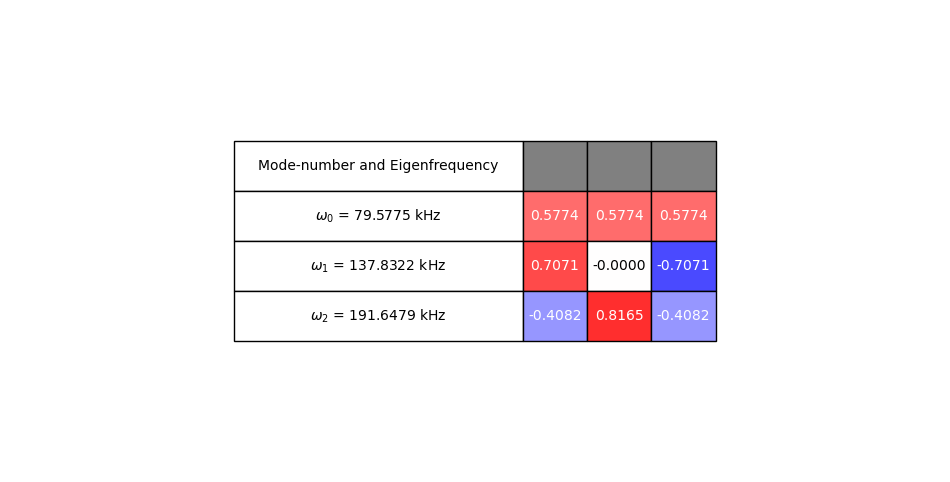

In [108]:
data = base

# Creating the plot
fig, ax = plt.subplots(figsize=(12, 2 * len(data)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(data):
    # Convert omega from radians per second to kHz
    omega_mhz = (omega / (2 * np.pi)) / 1e3
    formatted_values = [f"{value:.4f}" for value in values]
    omega_label = f"$\omega_{{{index}}}$ = {omega_mhz:.4f} kHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ['Mode-number and Eigenfrequency'] + [" " for i in range(len(data[0][1]))]

# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(data[0][1]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=-1, vmax=1)

# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.3 < value < 0.3 else 'white')

# Set gold background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):  # Skip the top left corner cell
    table[0, j].set_facecolor('gray')
table[0, 0].set_facecolor('white')  # Keep the top left corner cell white

#plt.savefig("17_ions_modes_table.png")
plt.show()

In [109]:
N = 3
tweezed_ions = [0,1]
omega_a = 0.5e6*2*pi*np.ones(N)
omega_tweezer_r = np.zeros(N)
omega_tweezer_r[tweezed_ions] = fit
omega_combined_ar = np.sqrt(omega_tweezer_r**2 + omega_a**2)
ueq = ion_spacing(N,omega_a)[0]
ar_modes_gaussian = mode_calc_a(m,omega_combined_ar,ueq,N)


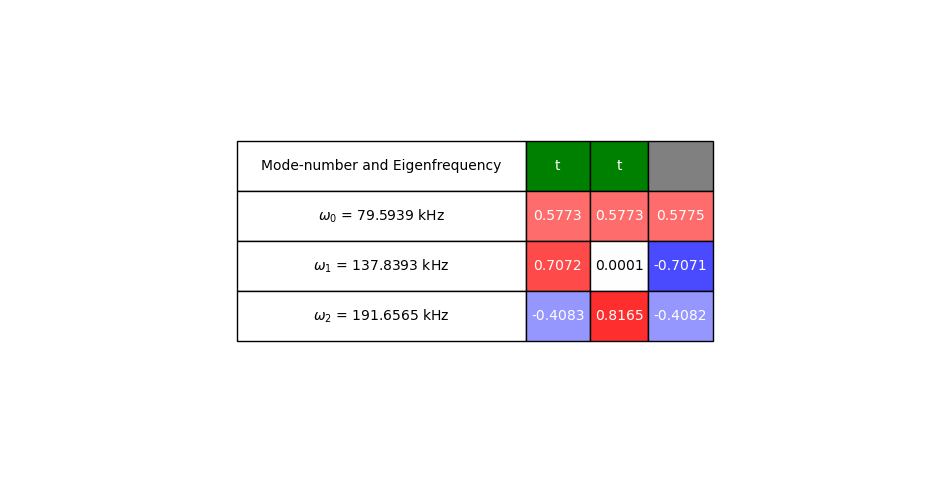

In [110]:
data = ar_modes_gaussian

# Creating the plot
fig, ax = plt.subplots(figsize=(12, 2 * len(data)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(data):
    # Convert omega from radians per second to kHz
    omega_mhz = (omega / (2 * np.pi)) / 1e3
    formatted_values = [f"{value:.4f}" for value in values]
    omega_label = f"$\omega_{{{index}}}$ = {omega_mhz:.4f} kHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels

column_labels = ['Mode-number and Eigenfrequency']  # Start with the label for the frequency column
for i in range(len(data[0][1])):
    if i  in [0,1]:  # These columns will have 't'
        column_labels.append('t')
    else:
        column_labels.append(' ')  # Other columns remain blank
# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(data[0][1]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=-1, vmax=1)

light_gray_columns = [2]
# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.3 < value < 0.3 else 'white')

# Special coloring for the first row
light_gray_columns = [0,1,2]
for j in range(1, len(column_labels)):  # Start from 1 to skip the first cell
    if j in light_gray_columns:
        table[0, j].set_facecolor('green')  # Set specified columns' background to blue
        table[0,j].set_text_props(color = 'white')
    else:
        table[0, j].set_facecolor('gray')  # Set other columns' background to gray
table[0, 0].set_facecolor('white')  # Set top left corner cell background to white

"""# Adjusting specific header cells for borders
for i in range(1, len(colWidths)):
    if i == 2:  # Correct index for m=0
        table[0, i].visible_edges = 'T'  # Top border only
    elif i == len(colWidths) - 1:  # Correct index for m=16
        table[0, i].visible_edges = 'TR'  # Top and Right borders
    else:
        table[0, i].visible_edges = 'T'  # Only top border for other cells"""

#plt.savefig("17_ions_modes_tweezed_table.png")
plt.show()